# Аттрактор Лоренца

## Базовый уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Реализуем метод Рунге-Кутты 4-го порядка для системы Лоренца:

\begin{equation*}
\begin{cases}
\dot x = \sigma (y - x)\\
\dot y = x (\rho - z) - y\\
\dot z = x y - \beta z
\end{cases}.
\end{equation*}

In [2]:
def f(x, sigma=10, rho=28, beta=8.0/3):
    return np.array([sigma * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - beta * x[2]])

def simulate(x0, n_steps, T, sigma=10, rho=28, beta=8.0/3):
    dt = T / n_steps
    x = np.zeros((3, n_steps + 1))
    x[:, 0] = x0
    for i in range(n_steps):
        k1 = f(x[:, i], sigma=sigma, rho=rho, beta=beta)
        k2 = f(x[:, i] + k1 * dt / 2, sigma=sigma, rho=rho, beta=beta)
        k3 = f(x[:, i] + k2 * dt / 2, sigma=sigma, rho=rho, beta=beta)
        k4 = f(x[:, i] + k3 * dt, sigma=sigma, rho=rho, beta=beta)
        x[:, i+1] = x[:, i] + (k1 + 2 * k2 + 2 * k3 + k4) * dt / 6

    return x

In [3]:
n_steps = 10000
traj_num = 2
T = 100.0
x = np.zeros((traj_num, 3, n_steps + 1))
x[0, :, :] = simulate(np.array([0.0, 1.0, 1.0]), n_steps, T)
x[1, :, :] = simulate(np.array([0.0, 1.0, 1.01]), n_steps, T)

Визуализируем решение системы.

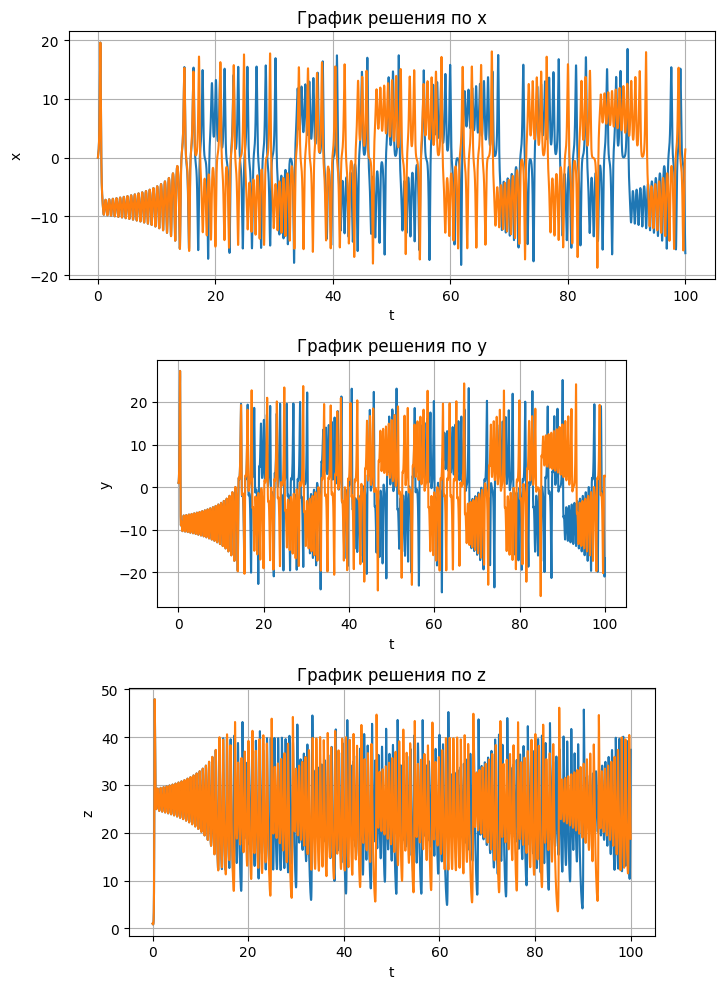

In [4]:
time_points = np.linspace(0.0, T, n_steps + 1)

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_title('График решения по x')
ax[1].set_title('График решения по y')
ax[2].set_title('График решения по z')
ax[0].plot(time_points, x[0, 0, :])
ax[1].plot(time_points, x[0, 1, :])
ax[2].plot(time_points, x[0, 2, :])
ax[0].plot(time_points, x[1, 0, :])
ax[1].plot(time_points, x[1, 1, :])
ax[2].plot(time_points, x[1, 2, :])
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[2].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
ax[2].set_ylabel('z')
fig.tight_layout()

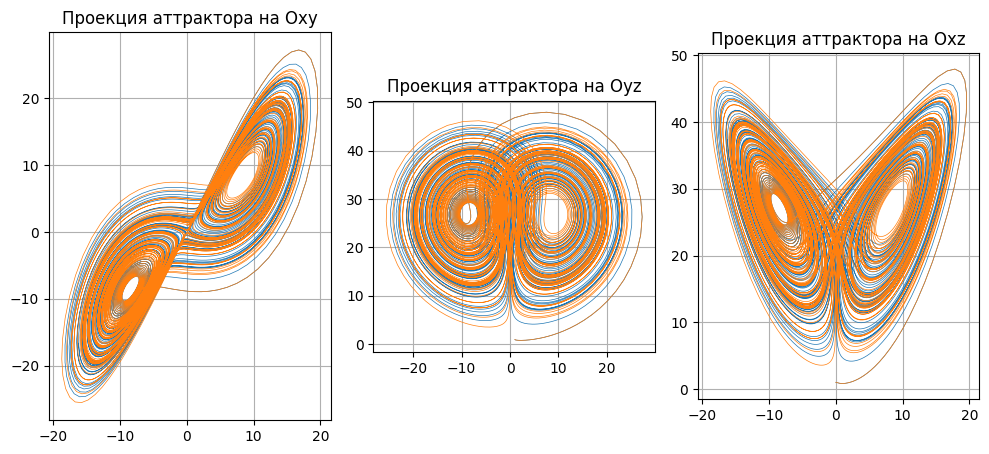

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_title('Проекция аттрактора на Oxy')
ax[1].set_title('Проекция аттрактора на Oyz')
ax[2].set_title('Проекция аттрактора на Oxz')
for i in range(traj_num):
    ax[0].plot(x[i, 0, :], x[i, 1, :], lw=0.5)
    ax[1].plot(x[i, 1, :], x[i, 2, :], lw=0.5)
    ax[2].plot(x[i, 0, :], x[i, 2, :], lw=0.5)
fig.tight_layout()


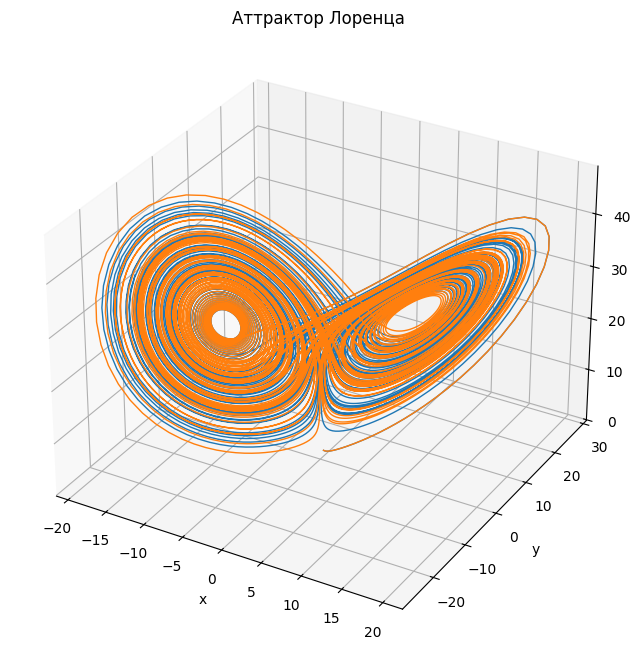

In [6]:
ax = plt.figure(figsize=(8, 8)).add_subplot(projection='3d')

for i in range(traj_num):
    ax.plot(*x[i, :, :], lw=1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Аттрактор Лоренца")

plt.show()

Оценим чувствительность данной системы к начальным данным.

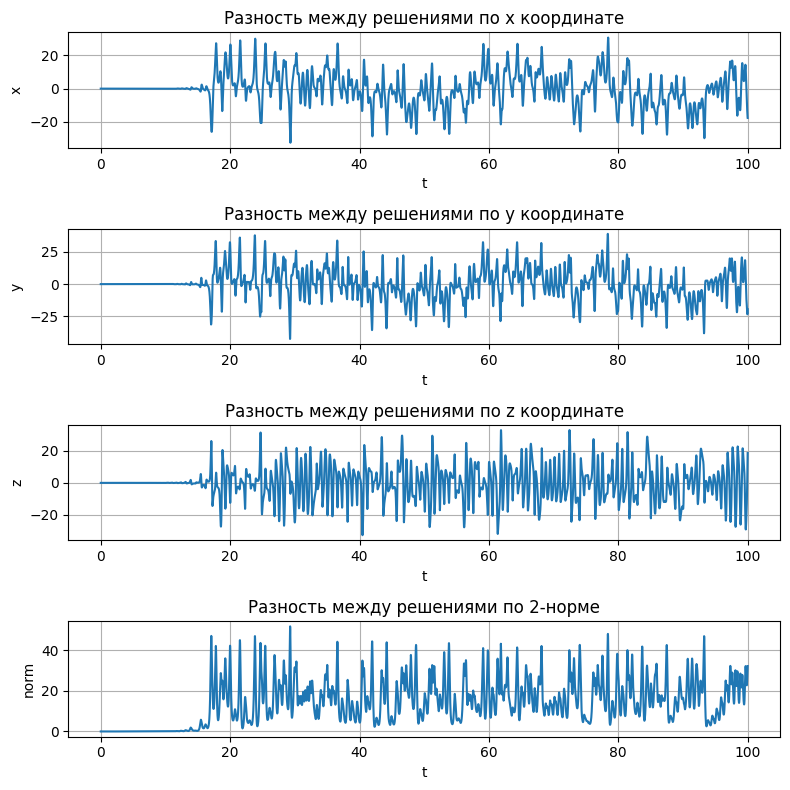

In [7]:
norm_diff = np.linalg.norm(x[0, :, :] - x[1, :, :], axis=0)

fig, ax = plt.subplots(4, figsize=(8, 8))
ax[0].plot(time_points, x[0, 0, :] - x[1, 0, :])
ax[0].grid(True)
ax[0].set_title('Разность между решениями по x координате')
ax[0].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].plot(time_points, x[0, 1, :] - x[1, 1, :])
ax[1].grid(True)
ax[1].set_title('Разность между решениями по y координате')
ax[1].set_xlabel('t')
ax[1].set_ylabel('y')
ax[2].plot(time_points, x[0, 2, :] - x[1, 2, :])
ax[2].grid(True)
ax[2].set_title('Разность между решениями по z координате')
ax[2].set_xlabel('t')
ax[2].set_ylabel('z')
ax[3].plot(time_points, norm_diff)
ax[3].grid(True)
ax[3].set_title('Разность между решениями по 2-норме')
ax[3].set_xlabel('t')
ax[3].set_ylabel('norm')
fig.tight_layout()
plt.show()

In [8]:
print('Смещение на {} в начальных условиях дало максимальную ошибку в {} на решении.'.format(np.linalg.norm(np.array([0.0, 1.0, 1.0]) - np.array([0.0, 1.0, 1.01])),
                                                                                            np.max(norm_diff)))

Смещение на 0.010000000000000009 в начальных условиях дало максимальную ошибку в 51.62713406474892 на решении.


Для данной системы наблюдается сильная чувствительность к изменениям начальных условий.

## Продвинутый уровень

### Варьирование параметра $\rho$

Визуализируем аттрактор для разных параметров $\rho$.

In [9]:
def poincare_x(x, y, z, val, n_steps):
    poincare_sec = [[], []]
    for i in range(n_steps):
        if (x[i] - val) * (x[i+1] - val) <= 0:
            y_inter = ((val - x[i]) * y[i] + (x[i+1] - val) * y[i+1]) / (x[i+1] - x[i])
            z_inter = ((val - x[i]) * z[i] + (x[i+1] - val) * z[i+1]) / (x[i+1] - x[i])
            poincare_sec[0].append(y_inter)
            poincare_sec[1].append(z_inter)
    return poincare_sec

def poincare_y(x, y, z, val, n_steps):
    poincare_sec = [[], []]
    for i in range(n_steps):
        if (y[i] - val) * (y[i+1] - val) <= 0:
            x_inter = ((val - y[i]) * x[i] + (y[i+1] - val) * x[i+1]) / (y[i+1] - y[i])
            z_inter = ((val - y[i]) * z[i] + (y[i+1] - val) * z[i+1]) / (y[i+1] - y[i])
            poincare_sec[0].append(x_inter)
            poincare_sec[1].append(z_inter)
    return poincare_sec

def poincare_z(x, y, z, val, n_steps):
    poincare_sec = [[], []]
    for i in range(n_steps):
        if (z[i] - val) * (z[i+1] - val) <= 0:
            x_inter = ((val - z[i]) * x[i] + (z[i+1] - val) * x[i+1]) / (z[i+1] - z[i])
            y_inter = ((val - z[i]) * y[i] + (z[i+1] - val) * y[i+1]) / (z[i+1] - z[i])
            poincare_sec[0].append(x_inter)
            poincare_sec[1].append(y_inter)
    return poincare_sec

def plot_poincare_x(x, i, x_val, n_steps):
    poincare_sec = poincare_x(x[i, 0, :], x[i, 1, :], x[i, 2, :], x_val, n_steps)
    fig = plt.figure()
    plt.scatter(poincare_sec[0], poincare_sec[1], s=2)
    plt.xlabel('y')
    plt.ylabel('z')
    plt.title('Сечение Пуанкаре при x = {}'.format(x_val))
    plt.show()

def plot_poincare_y(x, i, y_val, n_steps):
    poincare_sec = poincare_y(x[i, 0, :], x[i, 1, :], x[i, 2, :], y_val, n_steps)
    fig = plt.figure()
    plt.scatter(poincare_sec[0], poincare_sec[1], s=2)
    plt.xlabel('x')
    plt.ylabel('z')
    plt.title('Сечение Пуанкаре при y = {}'.format(y_val))
    plt.show()

def plot_poincare_z(x, i, z_val, n_steps):
    poincare_sec = poincare_z(x[i, 0, :], x[i, 1, :], x[i, 2, :], z_val, n_steps)
    fig = plt.figure()
    plt.scatter(poincare_sec[0], poincare_sec[1], s=2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Сечение Пуанкаре при z = {}'.format(z_val))
    plt.show()

In [10]:
param_num = 100
rho_values = np.linspace(1.0, 50.0, param_num)

n_steps = 10000
T = 100.0
x = np.zeros((param_num, 3, n_steps + 1))

poincare_sections = []

for i in range(param_num):
    x[i, :, :] = simulate(np.array([0.0, 1.0, 1.0]), n_steps, T, rho=rho_values[i])
    poincare_sections.append(poincare_x(x[i, 0, :], x[i, 1, :], x[i, 2, :], 0, n_steps)[1])

In [11]:
def visualize(i):
    fig, ax = plt.subplots(1, 3, figsize=(10, 10))
    ax[0].set_aspect('equal')
    ax[1].set_aspect('equal')
    ax[2].set_aspect('equal')
    ax[0].grid(True)
    ax[1].grid(True)
    ax[2].grid(True)
    ax[0].set_title('Проекция решения на Oxy')
    ax[1].set_title('Проекция решения на Oyz')
    ax[2].set_title('Проекция решения на Oxz')
    ax[0].plot(x[i, 0, :], x[i, 1, :], lw=0.5)
    ax[1].plot(x[i, 1, :], x[i, 2, :], lw=0.5)
    ax[2].plot(x[i, 0, :], x[i, 2, :], lw=0.5)
    fig.tight_layout()

    print(r'Значение \rho =', rho_values[i])

    plt.show()

    ax = plt.figure(figsize=(8, 8)).add_subplot(projection='3d')

    ax.plot(*x[i, :, :], lw=1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Решение системы Лоренца")

    plt.show()

При $\rho = 8.42$ система имеет точки устойчивого равновесия, к которым спиралью приближаются траектории системы.

Значение \rho = 8.424242424242426


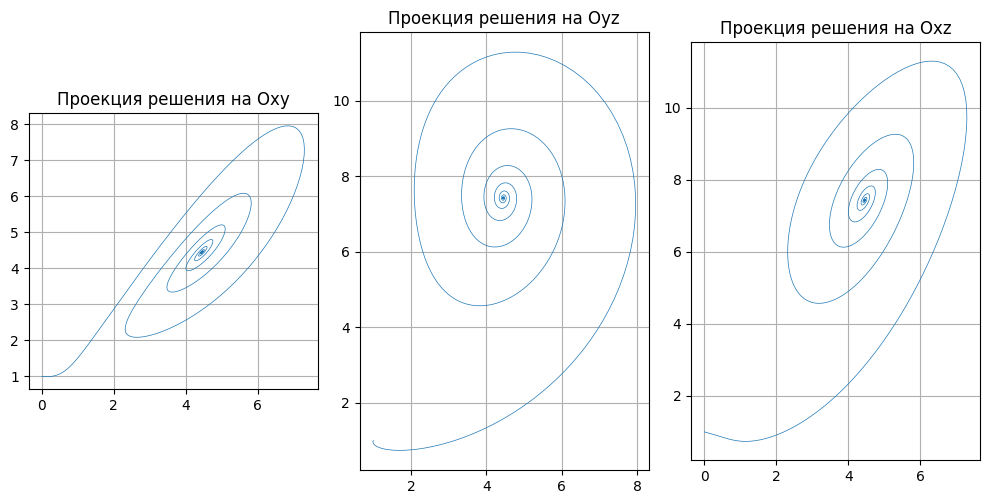

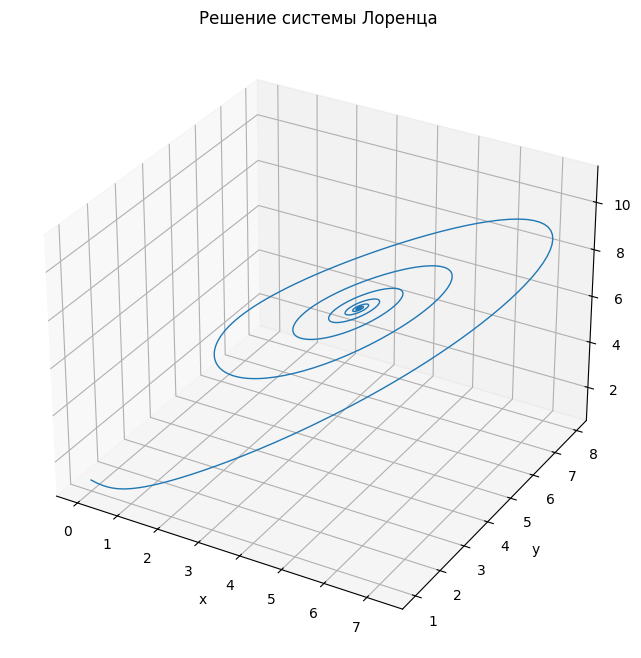

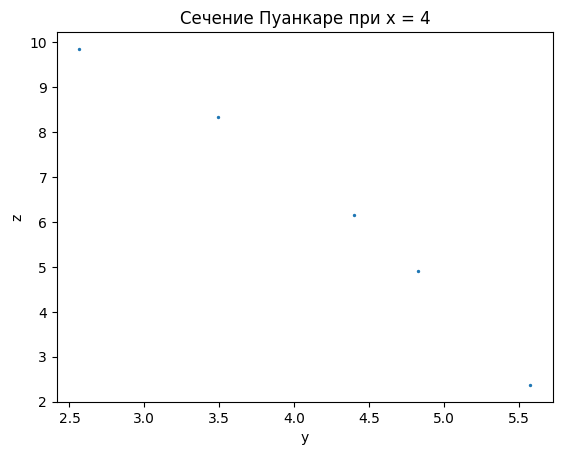

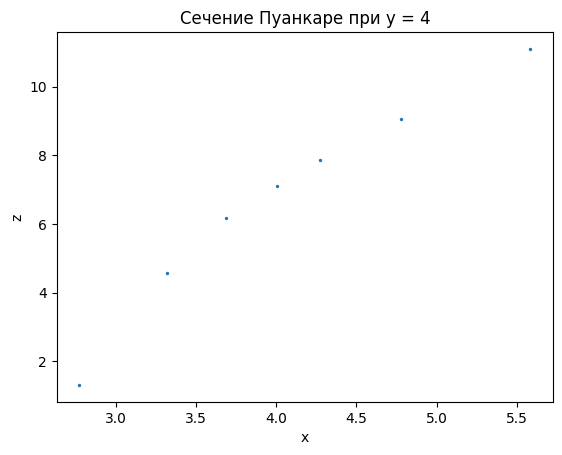

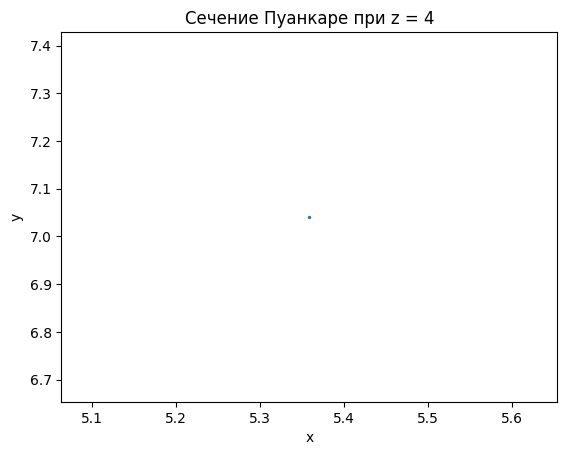

In [12]:
visualize(15)
plot_poincare_x(x, 15, 4, n_steps)
plot_poincare_y(x, 15, 4, n_steps)
plot_poincare_z(x, 15, 4, n_steps)

Значение \rho = 13.373737373737374


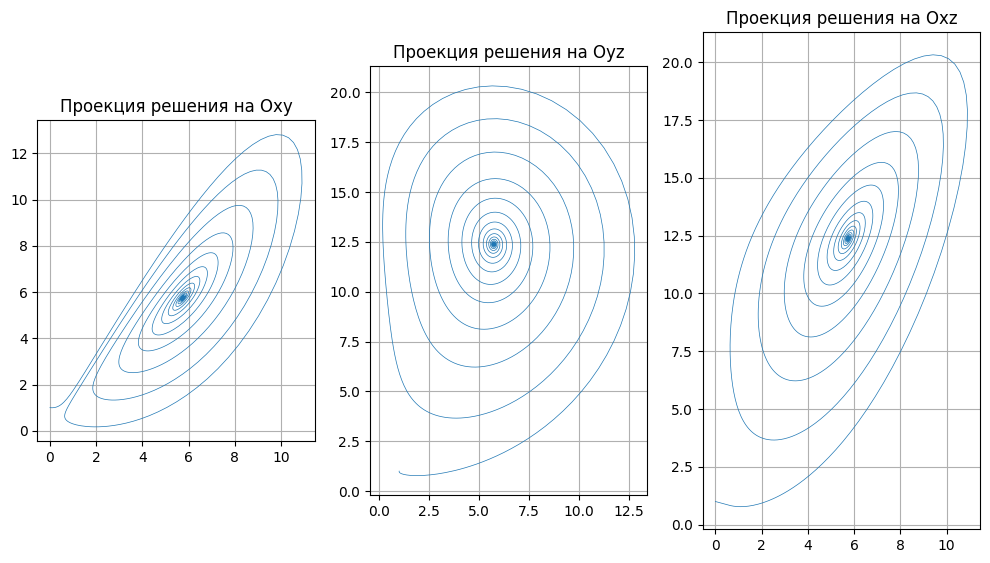

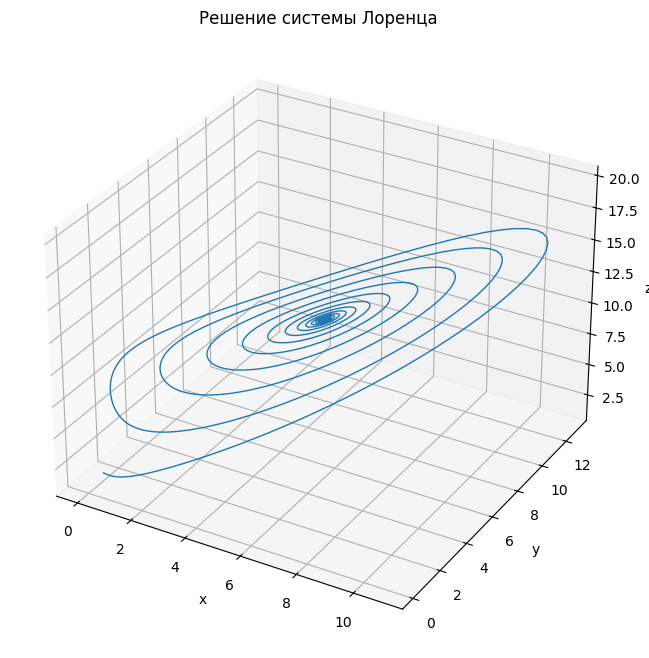

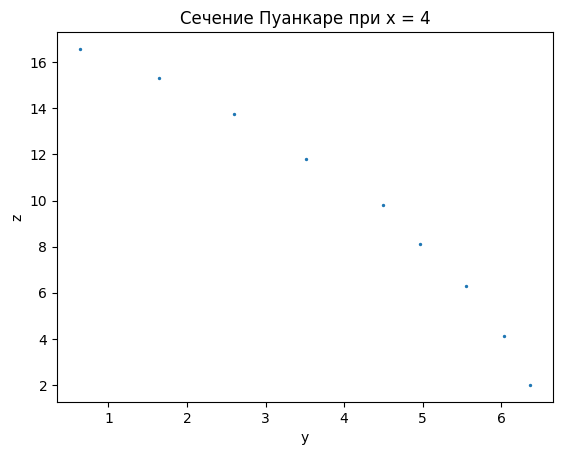

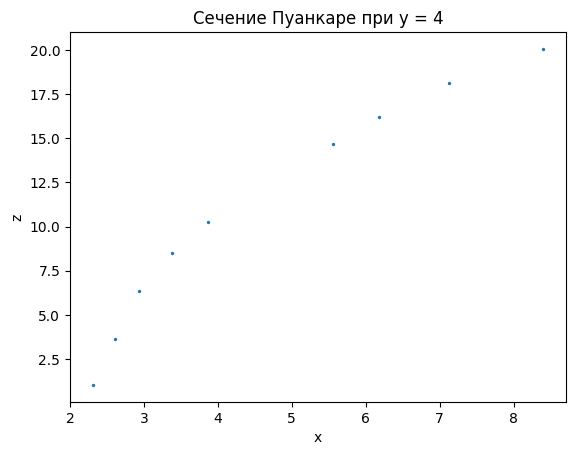

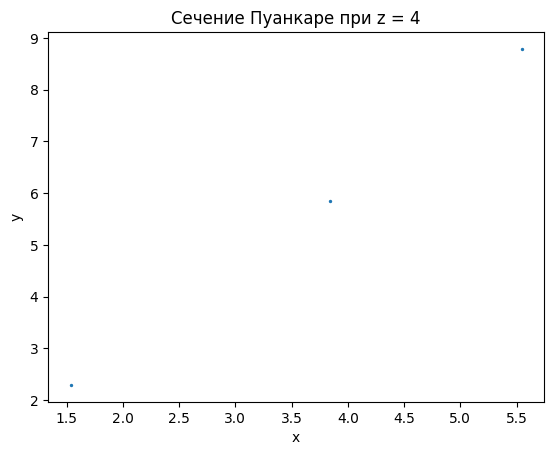

In [13]:
visualize(25)
plot_poincare_x(x, 25, 4, n_steps)
plot_poincare_y(x, 25, 4, n_steps)
plot_poincare_z(x, 25, 4, n_steps)

Значение \rho = 18.323232323232325


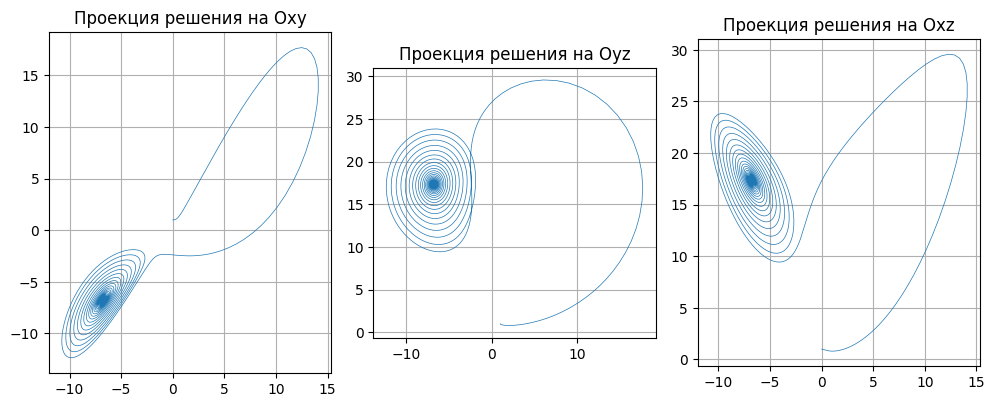

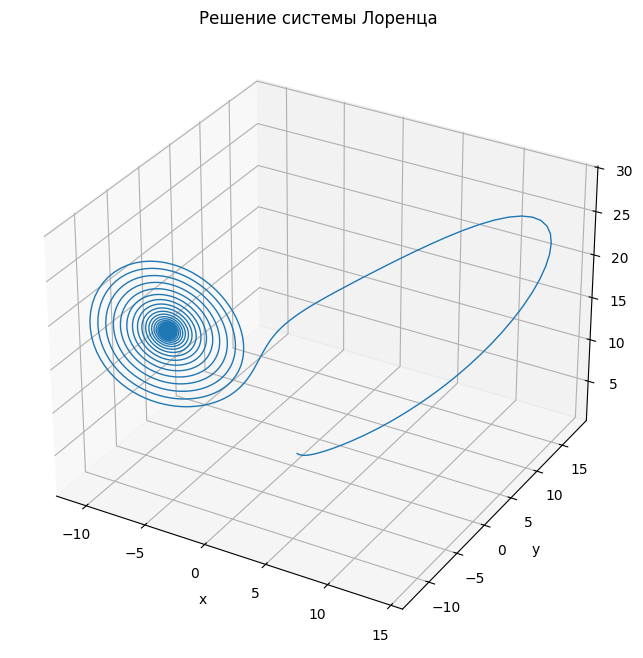

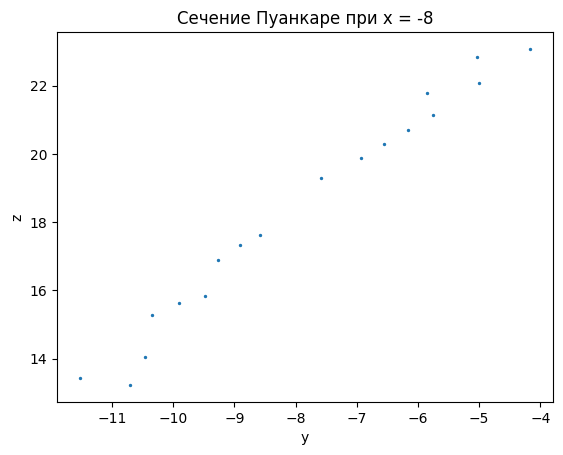

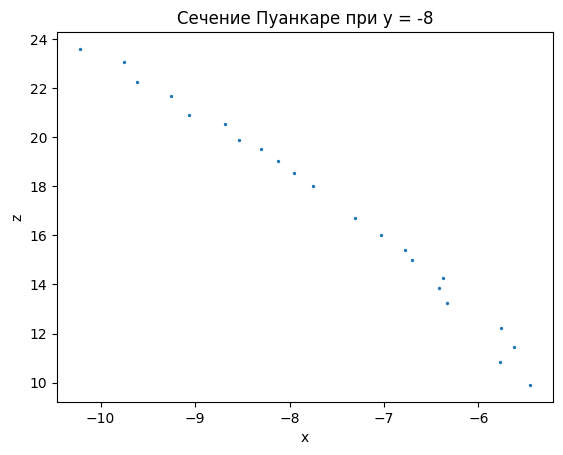

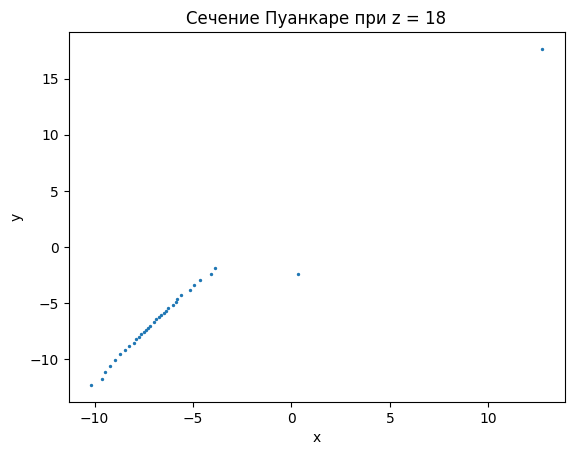

In [14]:
visualize(35)
plot_poincare_x(x, 35, -8, n_steps)
plot_poincare_y(x, 35, -8, n_steps)
plot_poincare_z(x, 35, 18, n_steps)

Значение \rho = 23.272727272727273


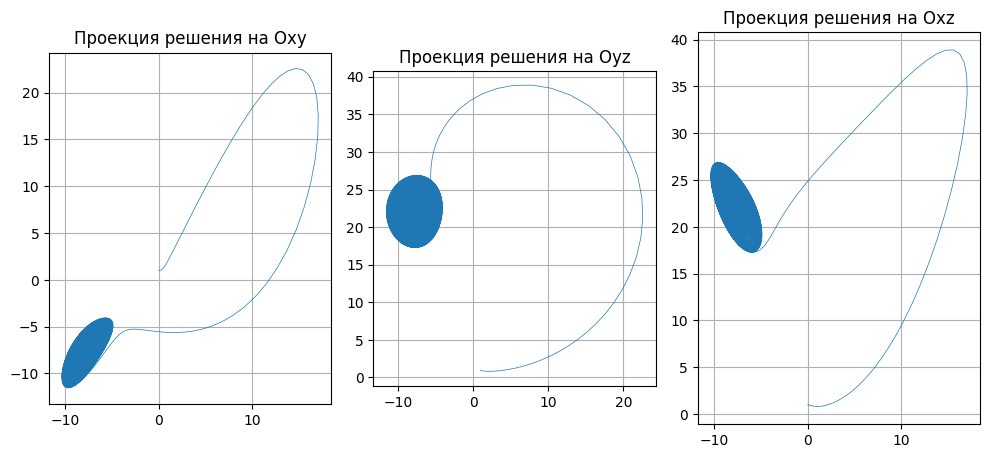

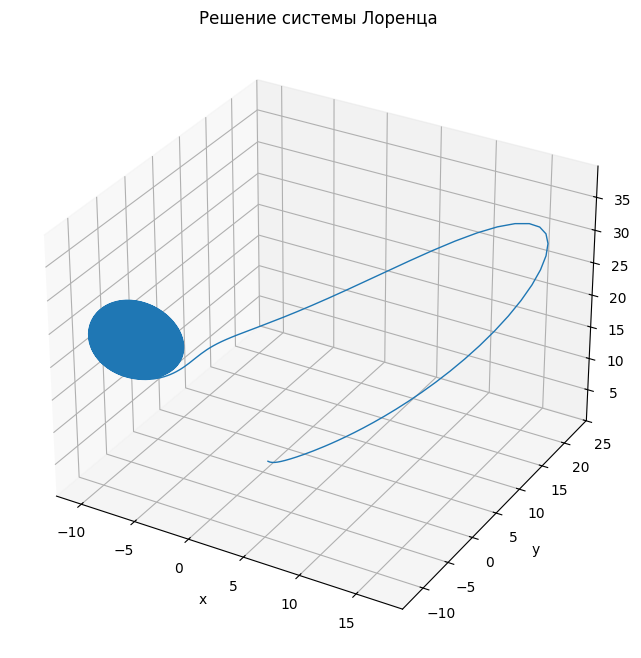

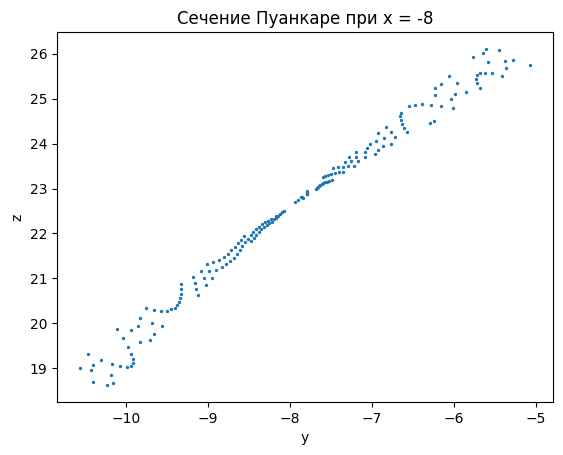

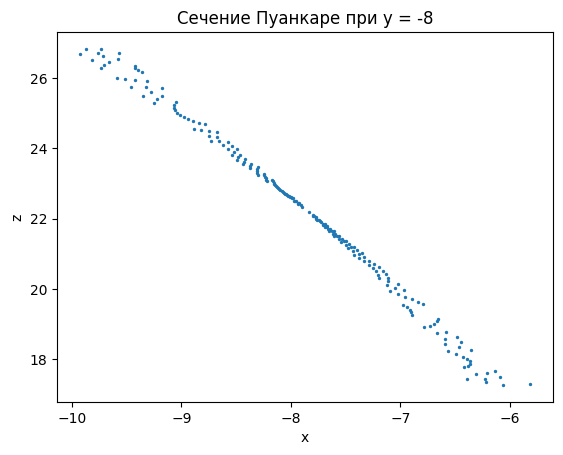

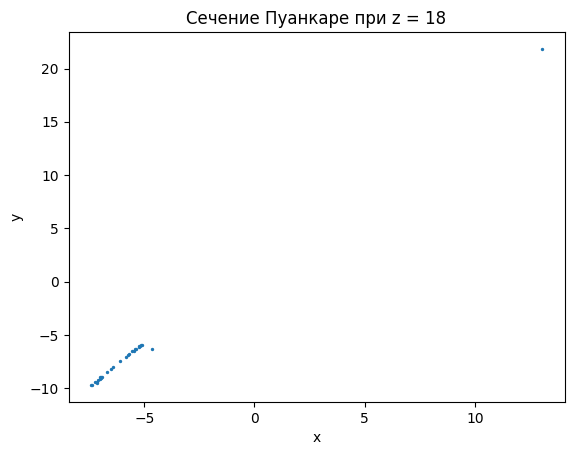

In [15]:
visualize(45)
plot_poincare_x(x, 45, -8, n_steps)
plot_poincare_y(x, 45, -8, n_steps)
plot_poincare_z(x, 45, 18, n_steps)

Значение \rho = 23.767676767676768


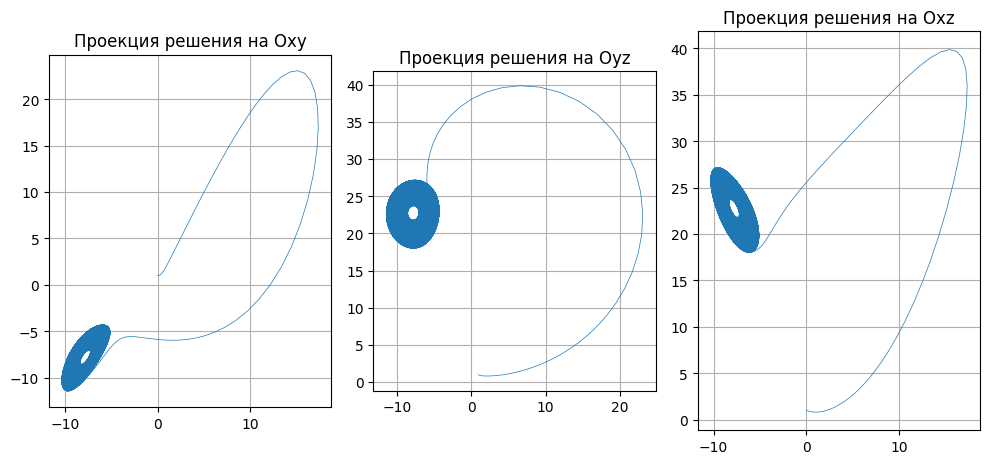

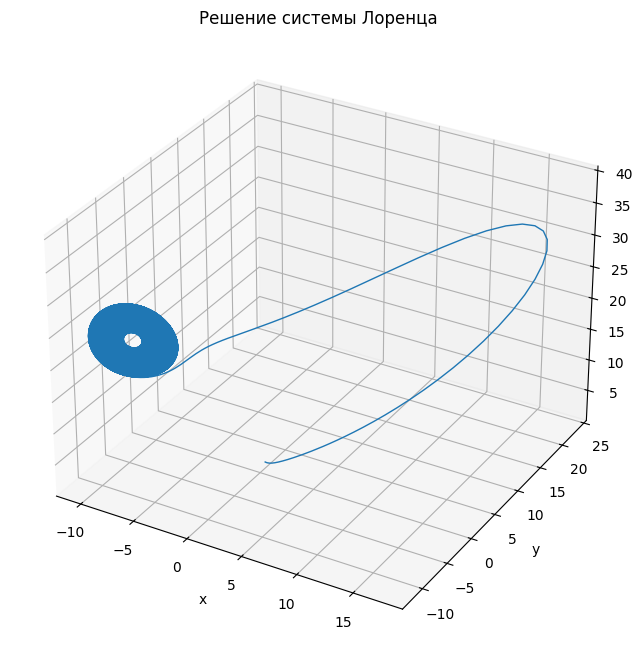

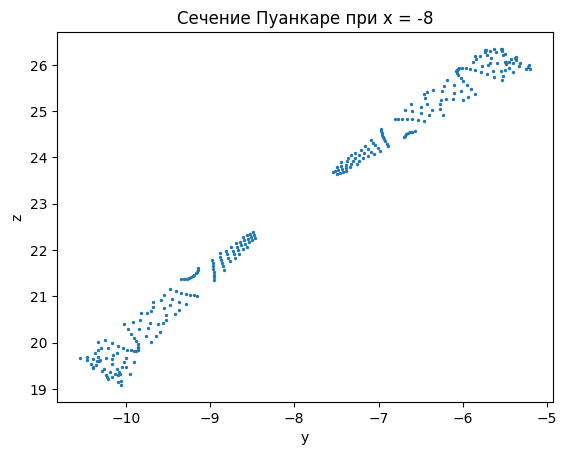

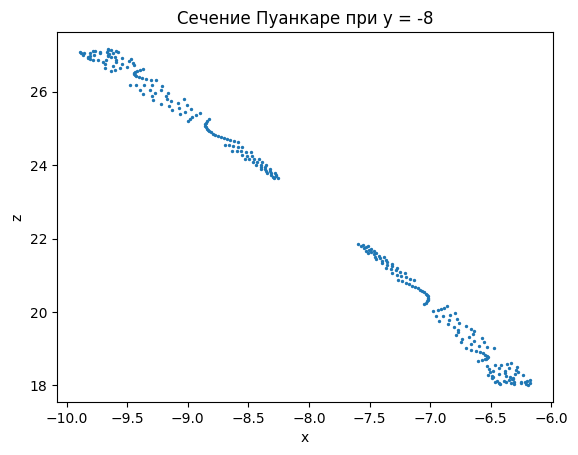

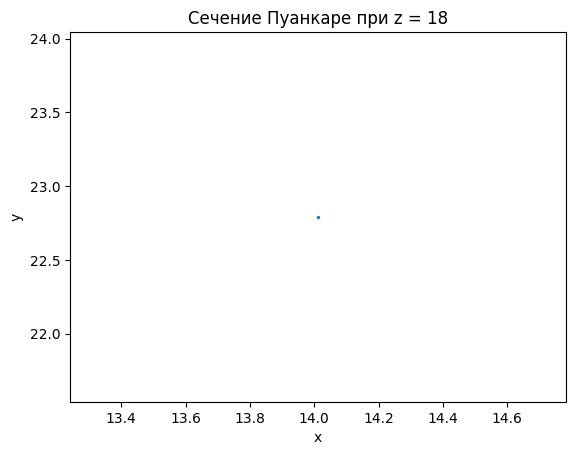

In [16]:
visualize(46)
plot_poincare_x(x, 46, -8, n_steps)
plot_poincare_y(x, 46, -8, n_steps)
plot_poincare_z(x, 46, 18, n_steps)

При значении параметра $\rho = 24.26$ возникает аттрактор Лоренца.

Значение \rho = 24.262626262626263


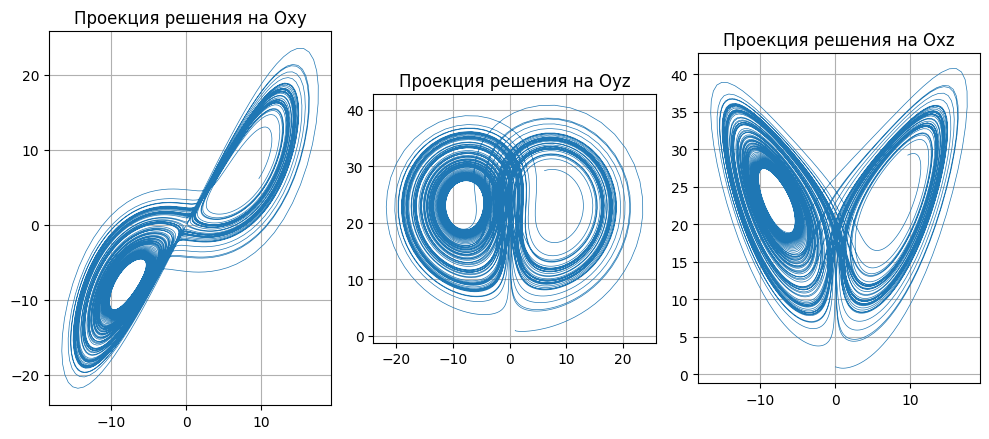

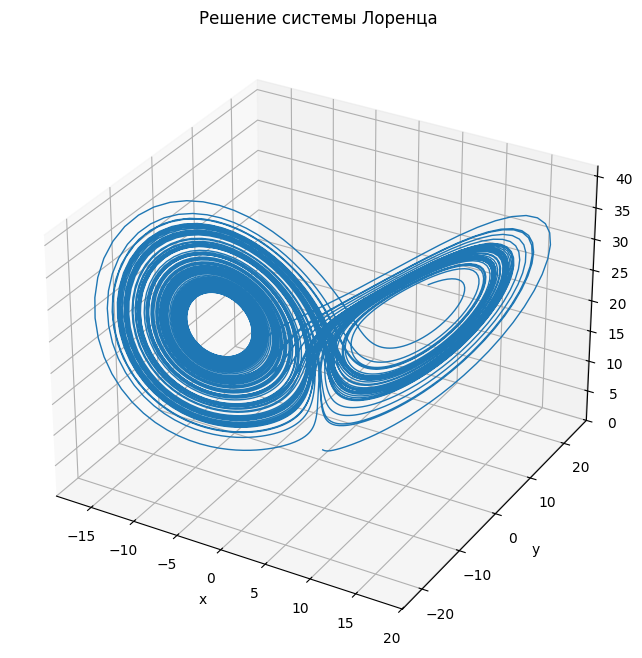

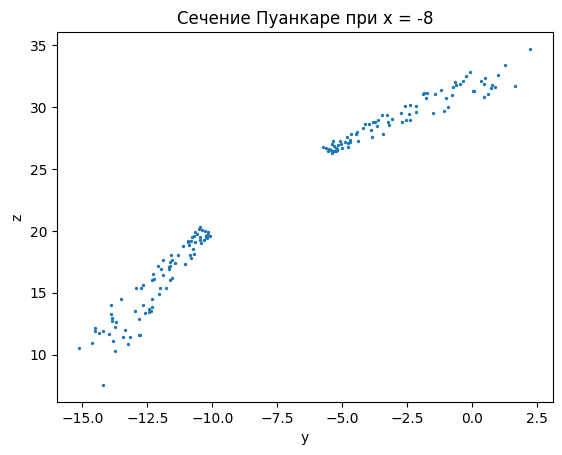

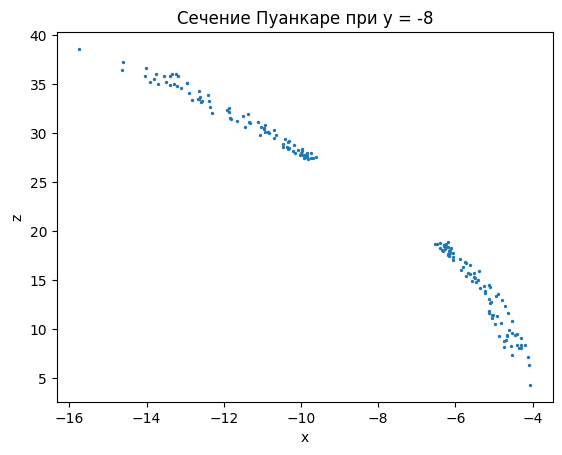

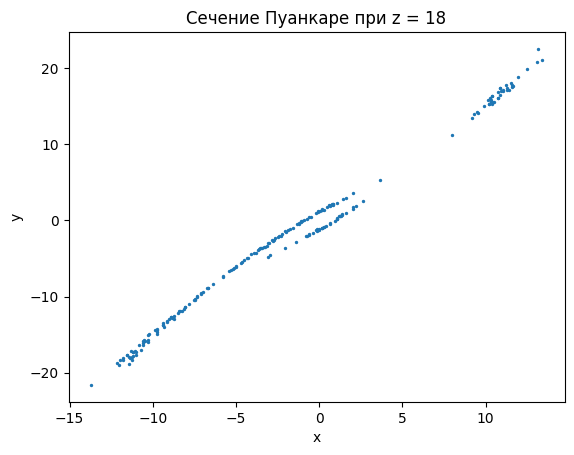

In [17]:
visualize(47)
plot_poincare_x(x, 47, -8, n_steps)
plot_poincare_y(x, 47, -8, n_steps)
plot_poincare_z(x, 47, 18, n_steps)

Значение \rho = 28.222222222222225


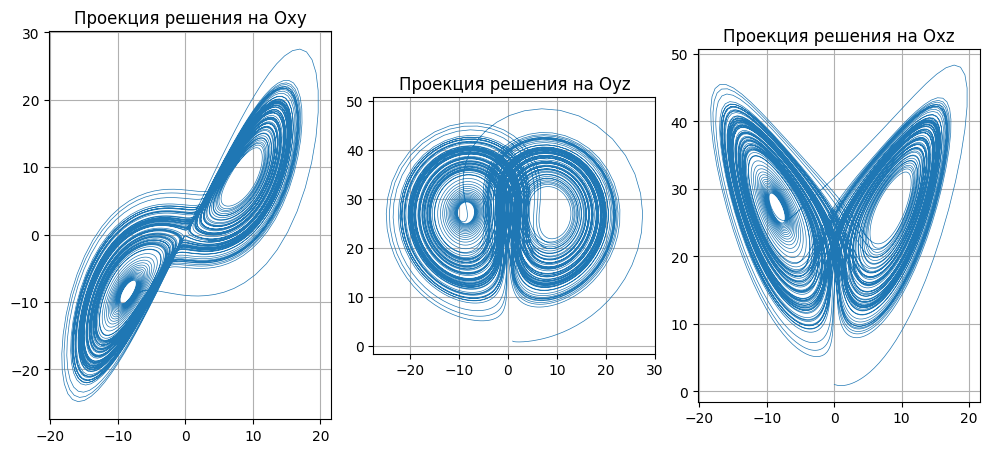

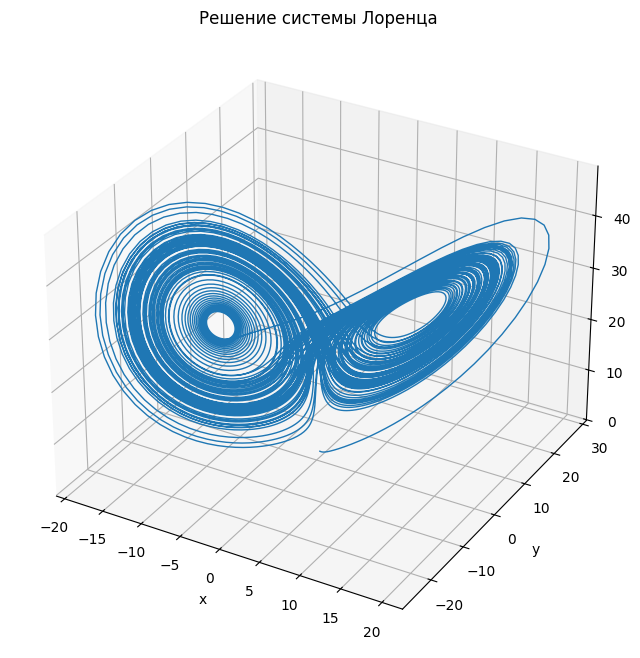

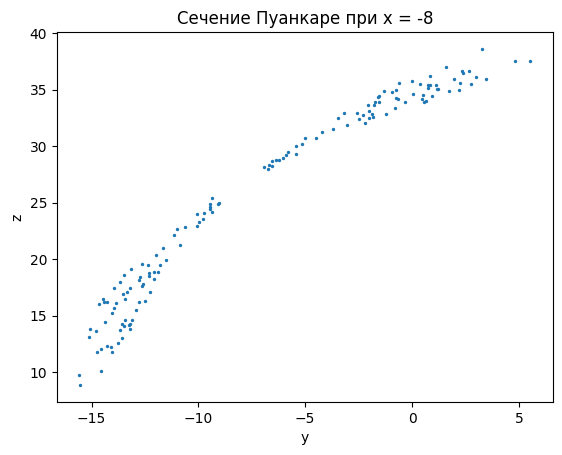

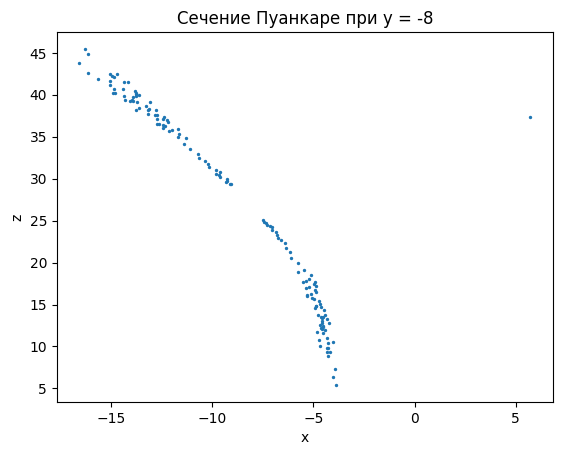

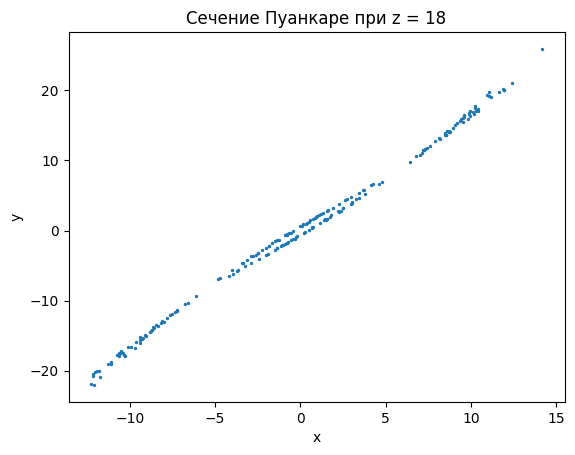

In [18]:
visualize(55)
plot_poincare_x(x, 55, -8, n_steps)
plot_poincare_y(x, 55, -8, n_steps)
plot_poincare_z(x, 55, 18, n_steps)

Построим бифуркационную диаграмму, варьируя $\rho$. Будем выводить на графике значения координаты $z$ точек в сечении Пуанкаре $x = 0$.

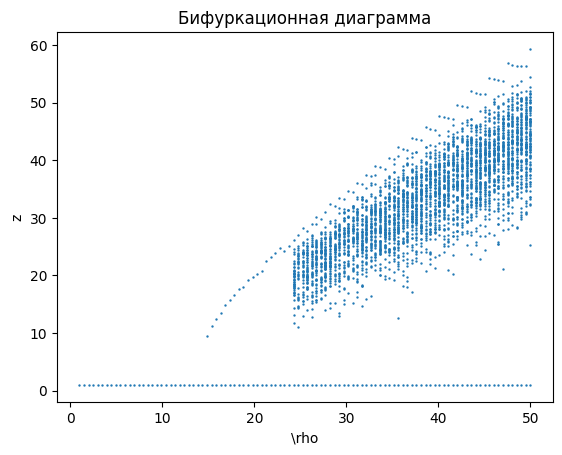

In [19]:
temp_x = []
temp_y = []
for i in range(param_num):
    for j in range(len(poincare_sections[i])):
        temp_x.append(rho_values[i])
        temp_y.append(poincare_sections[i][j])

fig = plt.figure()
plt.scatter(temp_x, temp_y, s=0.5)
plt.title('Бифуркационная диаграмма')
plt.xlabel(r'\rho')
plt.ylabel('z')
plt.show()

При значении $\rho$ в районе 24 происходит возникновение аттрактора Лоренца.